# Gradients and gradient descent

Week 2 extends derivatives and optimization from functions of one variable to functions of two or more variables. The central ideas will be tangent planes, gradients, and gradient descent.

## Welcome to Week 2

In Week 1, a function such as $f(x)$ had one input and one output. Its derivative described the slope of a tangent line.

This week considers functions such as

$$
f(x,y),
$$

which have two inputs and one output. A graph of such a function requires three axes:

- $x$ and $y$ are the two input coordinates;
- $z=f(x,y)$ is the output, plotted as height.

A tangent line generalizes to a **tangent plane**. These multivariable slopes can also guide optimization, but searching through many variables is more difficult. Gradient descent will provide an efficient iterative method for that search.

## Video 1 — From tangent lines to tangent planes

Start with the one-variable function

$$
f(x)=x^2.
$$

At $x=2$, the graph contains $(2,f(2))=(2,4)$. Its derivative is $f'(x)=2x$, so the tangent slope at $x=2$ is

$$
f'(2)=4.
$$

The tangent line is therefore

$$
y=4+4(x-2).
$$

### A function of two variables

Now consider

$$
f(x,y)=x^2+y^2.
$$

The inputs $(x,y)$ select a location in the horizontal plane, and the output gives the surface height $z=f(x,y)$.

The lecture examines $x=2$ and $y=4$. Its height is

$$
f(2,4)=2^2+4^2=4+16=20,
$$

so the point on the surface is $(2,4,20)$.

### Slice 1: hold $y=4$ fixed

Fixing $y=4$ cuts the surface in one direction:

$$
\begin{aligned}
f(x,4)&=x^2+4^2 \\
&=x^2+16.
\end{aligned}
$$

While differentiating with respect to $x$, the value $16$ is constant:

$$
\frac{d}{dx}f(x,4)=2x.
$$

At $x=2$, this slice has tangent slope $2(2)=4$. This measures how the height changes in the $x$ direction while $y$ stays fixed at $4$.

### Slice 2: hold $x=2$ fixed

Cut the surface in the other direction by fixing $x=2$:

$$
\begin{aligned}
f(2,y)&=2^2+y^2 \\
&=4+y^2.
\end{aligned}
$$

Differentiate with respect to $y$:

$$
\frac{d}{dy}f(2,y)=2y.
$$

At $y=4$, this slice has tangent slope $2(4)=8$. This measures how the height changes in the $y$ direction while $x$ stays fixed at $2$.

These one-direction derivatives will be formalized as **partial derivatives** in the next lessons.

### The two tangent lines determine the tangent plane

At $(2,4,20)$, the two slice slopes are

$$
\text{$x$-direction slope}=4
\qquad\text{and}\qquad
\text{$y$-direction slope}=8.
$$

The corresponding tangent lines intersect at the surface point. Together, their two independent directions determine the tangent plane:

$$
\boxed{z=20+4(x-2)+8(y-4).}
$$

The term $4(x-2)$ adjusts height for movement in the $x$ direction, while $8(y-4)$ adjusts height for movement in the $y$ direction. Just as a tangent line locally approximates a curve, this tangent plane locally approximates the surface near $(2,4,20)$.

### Visualizing the generalization

The left plot shows the Week 1 tangent line. The right plot shows the Week 2 surface, its two slice curves, their tangent directions, and the tangent plane. The plane is shown only near the selected point because it is a local approximation.

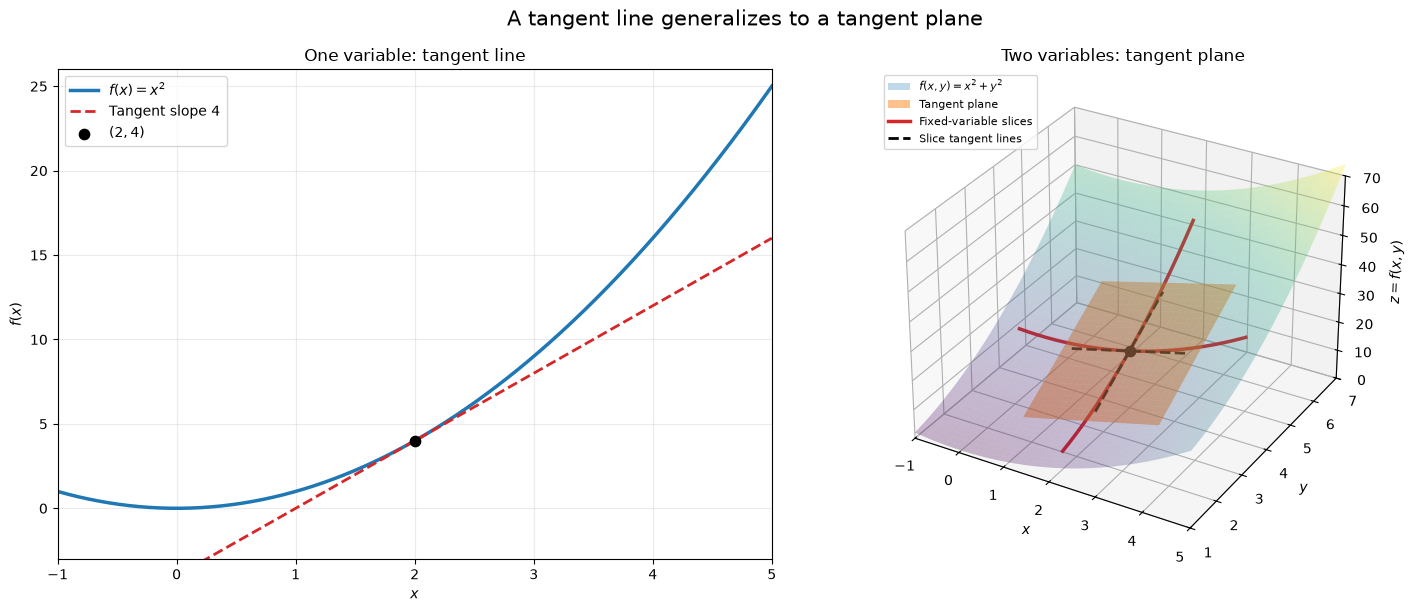

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig = plt.figure(figsize=(15, 6.2))

ax_curve = fig.add_subplot(1, 2, 1)
curve_inputs: np.ndarray = np.linspace(-1.0, 5.0, 350)
curve_outputs: np.ndarray = curve_inputs**2
curve_point_x: float = 2.0
curve_point_y: float = curve_point_x**2
curve_slope: float = 2.0 * curve_point_x
curve_tangent: np.ndarray = curve_point_y + curve_slope * (curve_inputs - curve_point_x)

ax_curve.plot(curve_inputs, curve_outputs, color="tab:blue", linewidth=2.5,
              label="$f(x)=x^2$")
ax_curve.plot(curve_inputs, curve_tangent, color="tab:red", linestyle="--", linewidth=2,
              label="Tangent slope $4$")
ax_curve.scatter([curve_point_x], [curve_point_y], color="black", s=55, zorder=3,
                 label="$(2,4)$")
ax_curve.set(title="One variable: tangent line", xlabel="$x$", ylabel="$f(x)$",
             xlim=(-1, 5), ylim=(-3, 26))
ax_curve.grid(alpha=0.25)
ax_curve.legend()

ax_surface = fig.add_subplot(1, 2, 2, projection="3d")
surface_x: np.ndarray = np.linspace(-1.0, 5.0, 90)
surface_y: np.ndarray = np.linspace(1.0, 7.0, 90)
surface_x_grid, surface_y_grid = np.meshgrid(surface_x, surface_y)
surface_z_grid: np.ndarray = surface_x_grid**2 + surface_y_grid**2
surface_point_x: float = 2.0
surface_point_y: float = 4.0
surface_point_z: float = surface_point_x**2 + surface_point_y**2
surface_x_slope: float = 2.0 * surface_point_x
surface_y_slope: float = 2.0 * surface_point_y

ax_surface.plot_surface(surface_x_grid, surface_y_grid, surface_z_grid, cmap="viridis",
                        alpha=0.28, linewidth=0)

plane_x: np.ndarray = np.linspace(0.5, 3.5, 25)
plane_y: np.ndarray = np.linspace(2.5, 5.5, 25)
plane_x_grid, plane_y_grid = np.meshgrid(plane_x, plane_y)
plane_z_grid: np.ndarray = (
    surface_point_z
    + surface_x_slope * (plane_x_grid - surface_point_x)
    + surface_y_slope * (plane_y_grid - surface_point_y)
)
ax_surface.plot_surface(plane_x_grid, plane_y_grid, plane_z_grid, color="tab:orange",
                        alpha=0.48, linewidth=0)

slice_x: np.ndarray = np.linspace(-0.5, 4.5, 220)
slice_y: np.ndarray = np.linspace(1.5, 6.5, 220)
ax_surface.plot(slice_x, np.full_like(slice_x, surface_point_y),
                slice_x**2 + surface_point_y**2, color="tab:red", linewidth=2.5)
ax_surface.plot(np.full_like(slice_y, surface_point_x), slice_y,
                surface_point_x**2 + slice_y**2, color="tab:red", linewidth=2.5)

x_tangent_inputs: np.ndarray = np.linspace(0.7, 3.3, 80)
y_tangent_inputs: np.ndarray = np.linspace(2.7, 5.3, 80)
ax_surface.plot(x_tangent_inputs, np.full_like(x_tangent_inputs, surface_point_y),
                surface_point_z + surface_x_slope * (x_tangent_inputs - surface_point_x),
                color="black", linestyle="--", linewidth=2)
ax_surface.plot(np.full_like(y_tangent_inputs, surface_point_x), y_tangent_inputs,
                surface_point_z + surface_y_slope * (y_tangent_inputs - surface_point_y),
                color="black", linestyle="--", linewidth=2)
ax_surface.scatter([surface_point_x], [surface_point_y], [surface_point_z], color="black",
                   s=55)

ax_surface.set(title="Two variables: tangent plane", xlabel="$x$", ylabel="$y$",
               zlabel="$z=f(x,y)$", xlim=(-1, 5), ylim=(1, 7), zlim=(0, 70))
legend_handles = [
    Patch(facecolor="tab:blue", alpha=0.28, label="$f(x,y)=x^2+y^2$"),
    Patch(facecolor="tab:orange", alpha=0.48, label="Tangent plane"),
    Line2D([0], [0], color="tab:red", linewidth=2.5, label="Fixed-variable slices"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=2,
           label="Slice tangent lines"),
]
ax_surface.legend(handles=legend_handles, fontsize=8, loc="upper left")

fig.suptitle("A tangent line generalizes to a tangent plane", fontsize=15)
fig.tight_layout()
plt.show()

### Takeaway

For $f(x,y)=x^2+y^2$ at $(x,y)=(2,4)$:

- fixing $y=4$ gives an $x$-direction slope of $4$;
- fixing $x=2$ gives a $y$-direction slope of $8$;
- the two slopes define the tangent plane

$$
z=20+4(x-2)+8(y-4).
$$

The next lessons will develop notation for these directional derivatives and combine them into the gradient, which gradient descent uses for multivariable optimization.

## Video 2 — Partial derivatives as slices

Before calculating partial derivatives, keep this mental picture:

1. Start with a surface representing a function of two variables.
2. Cut the surface with a vertical plane that holds one input fixed.
3. The intersection is a one-variable curve.
4. Draw a tangent line to that curve.

The tangent-line slope is a **partial derivative**. A different cutting direction produces a different curve and a different partial derivative.

### Hold one variable fixed

Consider again

$$
f(x,y)=x^2+y^2.
$$

If $y$ is fixed at some value, then $y^2$ is constant while $x$ changes. The surface slice becomes a one-variable function of $x$.

For example, fixing $y=4$ gives

$$
f(x,4)=x^2+16.
$$

Its tangent slope is found with the ordinary derivative with respect to $x$.

Likewise, fixing $x=2$ gives

$$
f(2,y)=4+y^2,
$$

which is a one-variable function of $y$.

### Partial-derivative notation

The symbol $\partial$ indicates a partial derivative. The partial derivative with respect to $x$ can be written in two common ways:

$$
f_x(x,y)
\qquad\text{or}\qquad
\frac{\partial f}{\partial x}(x,y).
$$

The partial derivative with respect to $y$ can be written as

$$
f_y(x,y)
\qquad\text{or}\qquad
\frac{\partial f}{\partial y}(x,y).
$$

The denominator names the variable allowed to change. Every **other** input variable is treated as constant during that calculation.

### Differentiate with respect to $x$

Start with

$$
f(x,y)=x^2+y^2.
$$

When differentiating with respect to $x$:

- $x$ changes, so $\frac{\partial}{\partial x}x^2=2x$;
- $y$ is fixed, so $y^2$ behaves as a constant and $\frac{\partial}{\partial x}y^2=0$.

Therefore,

$$
\begin{aligned}
\frac{\partial f}{\partial x}
&=
\frac{\partial}{\partial x}(x^2+y^2) \\
&=2x+0 \\
&=\boxed{2x}.
\end{aligned}
$$

> Treating $y^2$ as constant does **not** mean that $y^2=1$. It means only that its value does not change while $x$ changes, so its derivative with respect to $x$ is zero.

### Differentiate with respect to $y$

Now allow $y$ to change and hold $x$ fixed:

- $x^2$ behaves as a constant, so $\frac{\partial}{\partial y}x^2=0$;
- $y$ changes, so $\frac{\partial}{\partial y}y^2=2y$.

Therefore,

$$
\begin{aligned}
\frac{\partial f}{\partial y}
&=
\frac{\partial}{\partial y}(x^2+y^2) \\
&=0+2y \\
&=\boxed{2y}.
\end{aligned}
$$

At $(x,y)=(2,4)$, the two partial derivatives are

$$
\frac{\partial f}{\partial x}(2,4)=4
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}(2,4)=8.
$$

### The two-step procedure

To calculate a partial derivative:

1. Choose the variable with respect to which you are differentiating.
2. Treat every **other** variable as constant and use the usual one-variable derivative rules.

For $f(x,y)=x^2+y^2$:

| Requested derivative | Changing variable | Fixed variable | Result |
|---|---|---|---|
| $\frac{\partial f}{\partial x}$ | $x$ | $y$ | $2x$ |
| $\frac{\partial f}{\partial y}$ | $y$ | $x$ | $2y$ |

A function of ten input variables can have ten first partial derivatives—one for the rate of change along each coordinate direction.

### The two one-variable slices

The following plots isolate the two surface cuts. Each red curve is an ordinary parabola, and each black dashed line is its tangent at the selected point.

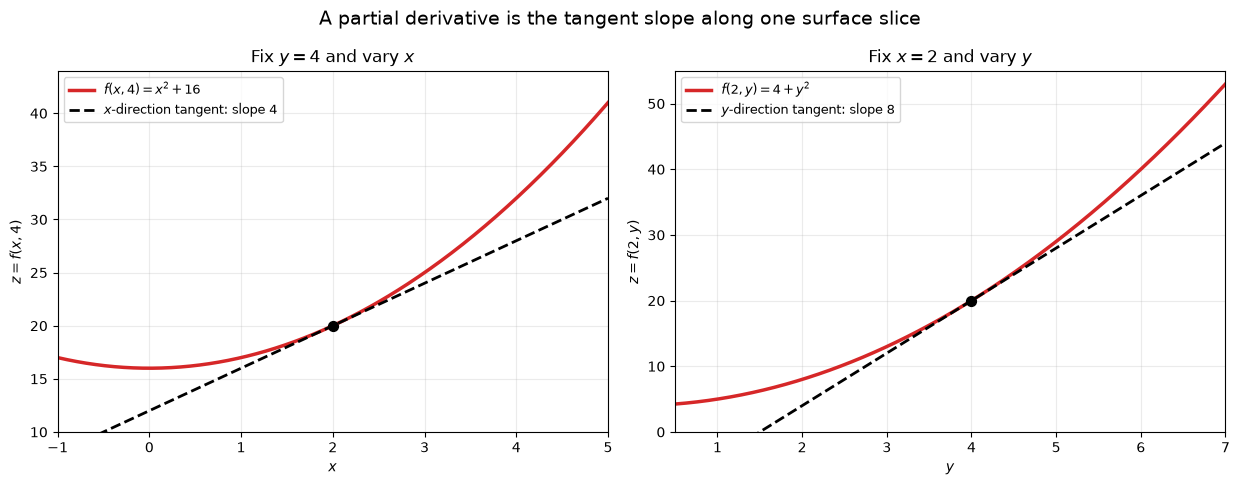

In [2]:
partial_x_inputs: np.ndarray = np.linspace(-1.0, 5.0, 350)
partial_y_inputs: np.ndarray = np.linspace(0.5, 7.0, 350)
partial_point_x: float = 2.0
partial_point_y: float = 4.0
partial_point_z: float = partial_point_x**2 + partial_point_y**2
partial_x_slope: float = 2.0 * partial_point_x
partial_y_slope: float = 2.0 * partial_point_y

x_slice_outputs: np.ndarray = partial_x_inputs**2 + partial_point_y**2
x_slice_tangent: np.ndarray = partial_point_z + partial_x_slope * (
    partial_x_inputs - partial_point_x
)
y_slice_outputs: np.ndarray = partial_point_x**2 + partial_y_inputs**2
y_slice_tangent: np.ndarray = partial_point_z + partial_y_slope * (
    partial_y_inputs - partial_point_y
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))

axes[0].plot(partial_x_inputs, x_slice_outputs, color="tab:red", linewidth=2.5,
             label="$f(x,4)=x^2+16$")
axes[0].plot(partial_x_inputs, x_slice_tangent, color="black", linestyle="--",
             linewidth=2, label="$x$-direction tangent: slope $4$")
axes[0].scatter([partial_point_x], [partial_point_z], color="black", s=50, zorder=3)
axes[0].set(title="Fix $y=4$ and vary $x$", xlabel="$x$", ylabel="$z=f(x,4)$",
            xlim=(-1, 5), ylim=(10, 44))
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(partial_y_inputs, y_slice_outputs, color="tab:red", linewidth=2.5,
             label="$f(2,y)=4+y^2$")
axes[1].plot(partial_y_inputs, y_slice_tangent, color="black", linestyle="--",
             linewidth=2, label="$y$-direction tangent: slope $8$")
axes[1].scatter([partial_point_y], [partial_point_z], color="black", s=50, zorder=3)
axes[1].set(title="Fix $x=2$ and vary $y$", xlabel="$y$", ylabel="$z=f(2,y)$",
            xlim=(0.5, 7), ylim=(0, 55))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle("A partial derivative is the tangent slope along one surface slice", fontsize=14)
fig.tight_layout()
plt.show()

### Takeaway

For

$$
f(x,y)=x^2+y^2,
$$

the two first partial derivatives are

$$
\boxed{
\frac{\partial f}{\partial x}=2x
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}=2y.
}
$$

Each derivative describes one directional tangent slope while the other coordinate remains fixed. Together, these slopes will become the components of the gradient.

## Video 3 — Partial derivatives of a product

Consider the two-variable function

$$
f(x,y)=3x^2y^3.
$$

The task is to find

$$
\frac{\partial f}{\partial x}
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}.
$$

Use the same two-step procedure:

1. Choose the variable allowed to change and treat every other variable as constant.
2. Apply the ordinary derivative rules to the changing variable.

### Differentiate with respect to $x$

When differentiating with respect to $x$, the value of $y$ is fixed. Therefore, both $3$ and $y^3$ act as constant multipliers:

$$
f(x,y)=\underbrace{3y^3}_{\text{constant with respect to }x}x^2.
$$

Keep that constant factor and differentiate $x^2$:

$$
\begin{aligned}
\frac{\partial f}{\partial x}
&=3y^3\frac{d}{dx}(x^2) \\
&=3y^3(2x) \\
&=\boxed{6xy^3}.
\end{aligned}
$$

The value $y^3$ remains because it scales how quickly the function changes as $x$ changes.

### Why the fixed factor remains

A fixed variable does not always disappear from a partial derivative. Its role depends on how it appears.

In a sum,

$$
\frac{\partial}{\partial x}(x^2+y^2)=2x+0,
$$

so the separate additive term $y^2$ disappears.

In a product,

$$
\frac{\partial}{\partial x}(x^2y^3)=y^3(2x),
$$

so the fixed $y^3$ remains as a multiplier. This is the same constant-multiple rule used for

$$
\frac{d}{dx}(5x^2)=5(2x).
$$

### Differentiate with respect to $y$

Now hold $x$ fixed. The factors $3$ and $x^2$ act as one constant multiplier:

$$
f(x,y)=\underbrace{3x^2}_{\text{constant with respect to }y}y^3.
$$

Differentiate $y^3$:

$$
\begin{aligned}
\frac{\partial f}{\partial y}
&=3x^2\frac{d}{dy}(y^3) \\
&=3x^2(3y^2) \\
&=\boxed{9x^2y^2}.
\end{aligned}
$$

### Comparing the two calculations

| Requested derivative | Changing factor | Fixed multiplier | Result |
|---|---|---|---|
| $\frac{\partial f}{\partial x}$ | $x^2\to2x$ | $3y^3$ | $6xy^3$ |
| $\frac{\partial f}{\partial y}$ | $y^3\to3y^2$ | $3x^2$ | $9x^2y^2$ |

The selected variable receives the power rule. Every other variable keeps its current power and behaves like part of the coefficient.

### Numerical verification at an illustrative point

The transcript does not specify a numerical point, so this check uses $(x,y)=(2,1.5)$. A centered finite difference approximates each partial derivative by changing one variable while keeping the other fixed.

In [3]:
def partial_product_function(x: float, y: float) -> float:
    """Evaluate f(x, y) = 3x^2y^3."""
    return 3.0 * x**2 * y**3


def partial_x_exact(x: float, y: float) -> float:
    """Evaluate the exact x partial derivative."""
    return 6.0 * x * y**3


def partial_y_exact(x: float, y: float) -> float:
    """Evaluate the exact y partial derivative."""
    return 9.0 * x**2 * y**2


verification_x: float = 2.0
verification_y: float = 1.5
verification_step: float = 1e-5
partial_x_finite_difference: float = (
    partial_product_function(verification_x + verification_step, verification_y)
    - partial_product_function(verification_x - verification_step, verification_y)
) / (2.0 * verification_step)
partial_y_finite_difference: float = (
    partial_product_function(verification_x, verification_y + verification_step)
    - partial_product_function(verification_x, verification_y - verification_step)
) / (2.0 * verification_step)
partial_x_expected: float = partial_x_exact(verification_x, verification_y)
partial_y_expected: float = partial_y_exact(verification_x, verification_y)

print(f"At (x, y) = ({verification_x}, {verification_y}):")
print(
    f"  ∂f/∂x: formula = {partial_x_expected:.6f}, "
    f"finite difference = {partial_x_finite_difference:.6f}"
)
print(
    f"  ∂f/∂y: formula = {partial_y_expected:.6f}, "
    f"finite difference = {partial_y_finite_difference:.6f}"
)

assert np.isclose(partial_x_expected, partial_x_finite_difference, rtol=1e-8)
assert np.isclose(partial_y_expected, partial_y_finite_difference, rtol=1e-8)

At (x, y) = (2.0, 1.5):
  ∂f/∂x: formula = 40.500000, finite difference = 40.500000
  ∂f/∂y: formula = 81.000000, finite difference = 81.000000


### Takeaway

For

$$
f(x,y)=3x^2y^3,
$$

the partial derivatives are

$$
\boxed{
\frac{\partial f}{\partial x}=6xy^3
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}=9x^2y^2.
}
$$

Hold the non-selected variable fixed as a multiplier, and apply the ordinary power rule only to the selected variable.

## Video 4 — The gradient vector

A function of two variables has two first partial derivatives: one for change in the $x$ direction and one for change in the $y$ direction.

The **gradient** collects those partial derivatives into one vector. It is written with the nabla symbol $\nabla$:

$$
\boxed{
\nabla f(x,y)
=
\begin{bmatrix}
\frac{\partial f}{\partial x}(x,y) \\
\frac{\partial f}{\partial y}(x,y)
\end{bmatrix}.
}
$$

The symbol $\nabla f$ is read as “the gradient of $f$.”

### Gradient of $f(x,y)=x^2+y^2$

For

$$
f(x,y)=x^2+y^2,
$$

the partial derivatives are

$$
\frac{\partial f}{\partial x}=2x
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}=2y.
$$

Place them in coordinate order, with the $x$ component first and the $y$ component second:

$$
\boxed{
\nabla f(x,y)
=
\begin{bmatrix}
2x \\
2y
\end{bmatrix}.
}
$$

Before selecting a point, the gradient is a vector-valued function: its entries still depend on $x$ and $y$.

### Evaluate the gradient at $(2,3)$

To evaluate the gradient at a point, substitute the point's coordinates into the corresponding entries:

$$
\begin{aligned}
\nabla f(2,3)
&=
\begin{bmatrix}
2(2) \\
2(3)
\end{bmatrix} \\
&=
\boxed{
\begin{bmatrix}
4 \\
6
\end{bmatrix}}.
\end{aligned}
$$

The first component, $4$, is the $x$-direction tangent slope. The second component, $6$, is the $y$-direction tangent slope at the same point.

### How the gradient describes the tangent plane

At $(x_0,y_0)$, the tangent plane can be written using the gradient components:

$$
z
=
f(x_0,y_0)
+
\frac{\partial f}{\partial x}(x_0,y_0)(x-x_0)
+
\frac{\partial f}{\partial y}(x_0,y_0)(y-y_0).
$$

For $(x_0,y_0)=(2,3)$,

$$
f(2,3)=2^2+3^2=13
$$

and

$$
\nabla f(2,3)=
\begin{bmatrix}4\\6\end{bmatrix}.
$$

Therefore, the tangent plane is

$$
z=13+4(x-2)+6(y-3).
$$

The gradient packages the two coefficients that describe the plane's coordinate-direction slopes.

### Visualizing the gradient at a point

The contour lines below connect points with equal values of $f(x,y)=x^2+y^2$. The arrow represents $\nabla f(2,3)=[4,6]^T$. Its horizontal and vertical changes match the two partial-derivative components.

The geometric direction of the gradient will become important for gradient descent in later lessons.

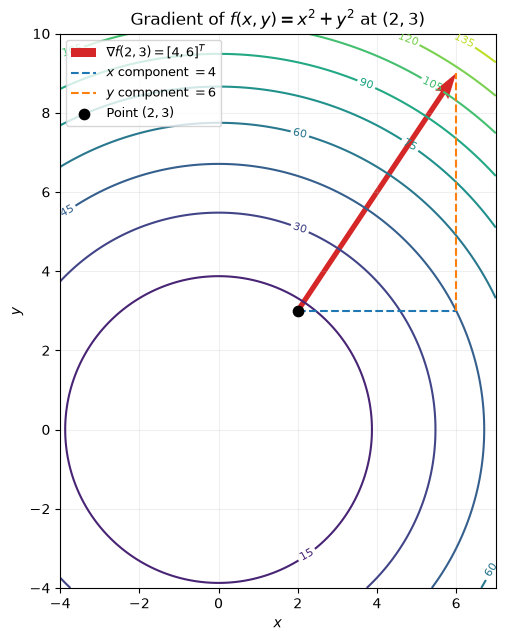

In [4]:
gradient_plot_x: np.ndarray = np.linspace(-4.0, 7.0, 250)
gradient_plot_y: np.ndarray = np.linspace(-4.0, 10.0, 250)
gradient_x_grid, gradient_y_grid = np.meshgrid(gradient_plot_x, gradient_plot_y)
gradient_values: np.ndarray = gradient_x_grid**2 + gradient_y_grid**2
gradient_point_x: float = 2.0
gradient_point_y: float = 3.0
gradient_component_x: float = 2.0 * gradient_point_x
gradient_component_y: float = 2.0 * gradient_point_y

fig, ax = plt.subplots(figsize=(7.2, 7.2))
contours = ax.contour(gradient_x_grid, gradient_y_grid, gradient_values, levels=12,
                      cmap="viridis")
ax.clabel(contours, inline=True, fontsize=8)
ax.quiver(gradient_point_x, gradient_point_y, gradient_component_x, gradient_component_y,
          angles="xy", scale_units="xy", scale=1, color="tab:red", width=0.012,
          label="$\\nabla f(2,3)=[4,6]^T$")
ax.plot([gradient_point_x, gradient_point_x + gradient_component_x],
        [gradient_point_y, gradient_point_y], color="tab:blue", linestyle="--",
        label="$x$ component $=4$")
ax.plot([gradient_point_x + gradient_component_x, gradient_point_x + gradient_component_x],
        [gradient_point_y, gradient_point_y + gradient_component_y], color="tab:orange",
        linestyle="--", label="$y$ component $=6$")
ax.scatter([gradient_point_x], [gradient_point_y], color="black", s=55, zorder=4,
           label="Point $(2,3)$")
ax.set(
    title="Gradient of $f(x,y)=x^2+y^2$ at $(2,3)$",
    xlabel="$x$",
    ylabel="$y$",
    xlim=(-4, 7),
    ylim=(-4, 10),
)
ax.set_aspect("equal")
ax.grid(alpha=0.2)
ax.legend(fontsize=9, loc="upper left")
plt.show()

### More input variables

For a function of $n$ variables,

$$
f(x_1,x_2,\ldots,x_n),
$$

the gradient contains one partial derivative for each variable:

$$
\nabla f
=
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}.
$$

A function of $17$ variables therefore has a gradient with $17$ components. Each component measures the rate of change along one coordinate direction while the other variables are held fixed.

### Takeaway

The gradient is the vector of all first partial derivatives:

$$
\boxed{
\nabla f(x,y)
=
\begin{bmatrix}
f_x(x,y) \\
f_y(x,y)
\end{bmatrix}.
}
$$

For $f(x,y)=x^2+y^2$,

$$
\nabla f(x,y)=
\begin{bmatrix}2x\\2y\end{bmatrix},
\qquad
\nabla f(2,3)=
\begin{bmatrix}4\\6\end{bmatrix}.
$$

The gradient condenses all coordinate-direction slopes into one object that can be used to describe tangent planes and guide multivariable optimization.

## Video 5 — Using the gradient to locate optima

In one variable, a derivative helps locate smooth interior maxima and minima. In several variables, the gradient plays the same role.

At a differentiable interior local maximum or minimum, the tangent plane is horizontal. Every coordinate-direction tangent slope is therefore zero, so every partial derivative is zero:

$$
\boxed{\nabla f=\mathbf{0}.}
$$

This is the multivariable version of solving $f'(x)=0$.

### Review: one-variable optimization

For

$$
f(x)=x^2,
$$

the derivative is

$$
f'(x)=2x.
$$

Set the derivative equal to zero:

$$
\begin{aligned}
2x&=0, \\
x&=0.
\end{aligned}
$$

At $x=0$, the tangent line is horizontal. Since $x^2\ge0$ for every real $x$ and $f(0)=0$, this point is the global minimum.

### Two-variable optimization

Now consider

$$
f(x,y)=x^2+y^2.
$$

Its gradient is

$$
\nabla f(x,y)
=
\begin{bmatrix}
2x \\
2y
\end{bmatrix}.
$$

For the gradient to be the zero vector, **both** components must be zero:

$$
\begin{bmatrix}
2x \\
2y
\end{bmatrix}
=
\begin{bmatrix}
0 \\
0
\end{bmatrix}.
$$

This vector equation represents a system of two equations:

$$
2x=0
\qquad\text{and}\qquad
2y=0.
$$

Therefore,

$$
\boxed{(x,y)=(0,0).}
$$

### Why $(0,0)$ is the minimum

At the origin,

$$
f(0,0)=0^2+0^2=0.
$$

Because squares are nonnegative,

$$
x^2+y^2\ge0
$$

for every real pair $(x,y)$. No point can have a smaller function value, so $(0,0)$ is the global minimum.

At this point,

$$
\frac{\partial f}{\partial x}=0
\qquad\text{and}\qquad
\frac{\partial f}{\partial y}=0.
$$

The two coordinate-direction tangent lines and the tangent plane are all parallel to the horizontal floor.

### A zero gradient gives candidates, not a guarantee

The precise statement is:

> If a differentiable function has an interior local maximum or minimum at a point, then its gradient is zero there.

The reverse is not always true. A point with zero gradient can instead be a **saddle point**, where the function rises in some directions and falls in others.

For example,

$$
s(x,y)=x^2-y^2
$$

has

$$
\nabla s(0,0)=
\begin{bmatrix}0\\0\end{bmatrix},
$$

but $(0,0)$ is neither a maximum nor a minimum. Thus, solving $\nabla f=\mathbf{0}$ finds stationary **candidates**, which must then be classified.

### Horizontal tangent line and tangent plane

The visual comparison below shows the zero-slope condition in one and two variables. In both cases, the optimum is at the origin and the tangent object is horizontal.

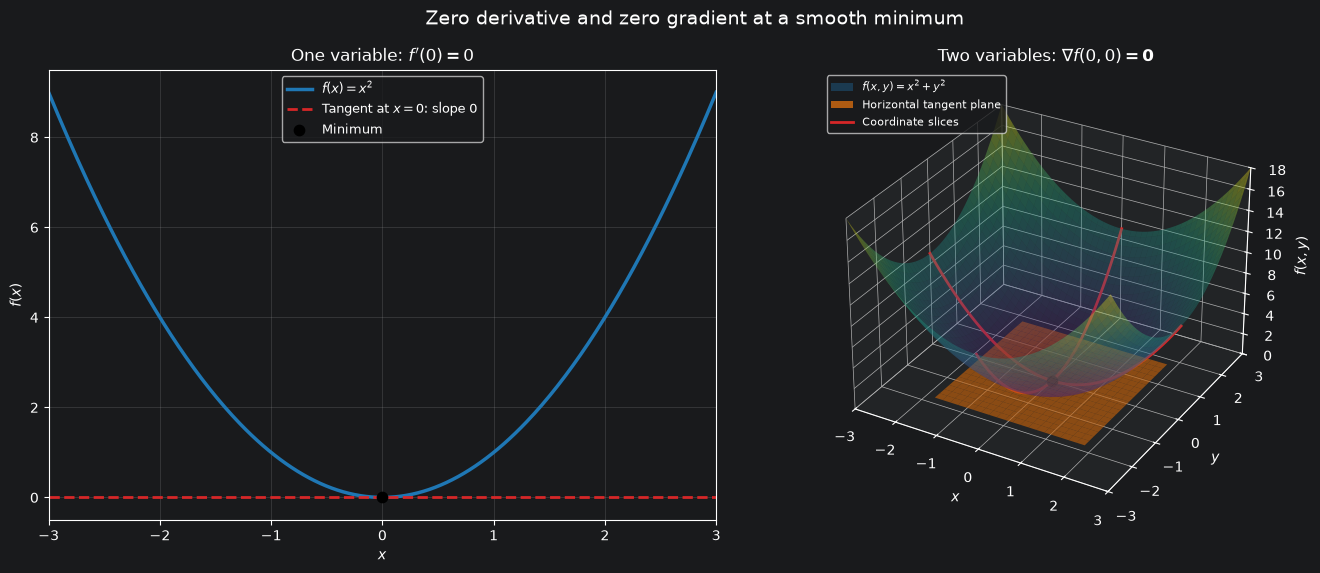

In [6]:
zero_gradient_curve_x: np.ndarray = np.linspace(-3.0, 3.0, 350)
zero_gradient_curve_y: np.ndarray = zero_gradient_curve_x**2

fig = plt.figure(figsize=(14, 5.8))
ax_zero_curve = fig.add_subplot(1, 2, 1)
ax_zero_curve.plot(zero_gradient_curve_x, zero_gradient_curve_y, color="tab:blue",
                   linewidth=2.5, label="$f(x)=x^2$")
ax_zero_curve.axhline(0, color="tab:red", linestyle="--", linewidth=2,
                      label="Tangent at $x=0$: slope $0$")
ax_zero_curve.scatter([0], [0], color="black", s=55, zorder=3, label="Minimum")
ax_zero_curve.set(title="One variable: $f'(0)=0$", xlabel="$x$", ylabel="$f(x)$",
                  xlim=(-3, 3), ylim=(-0.5, 9.5))
ax_zero_curve.grid(alpha=0.25)
ax_zero_curve.legend(fontsize=9)

ax_zero_surface = fig.add_subplot(1, 2, 2, projection="3d")
zero_gradient_surface_x: np.ndarray = np.linspace(-3.0, 3.0, 90)
zero_gradient_surface_y: np.ndarray = np.linspace(-3.0, 3.0, 90)
zero_gradient_x_grid, zero_gradient_y_grid = np.meshgrid(
    zero_gradient_surface_x, zero_gradient_surface_y
)
zero_gradient_z_grid: np.ndarray = zero_gradient_x_grid**2 + zero_gradient_y_grid**2
ax_zero_surface.plot_surface(zero_gradient_x_grid, zero_gradient_y_grid,
                             zero_gradient_z_grid, cmap="viridis", alpha=0.35,
                             linewidth=0)
zero_plane_x: np.ndarray = np.linspace(-1.8, 1.8, 20)
zero_plane_y: np.ndarray = np.linspace(-1.8, 1.8, 20)
zero_plane_x_grid, zero_plane_y_grid = np.meshgrid(zero_plane_x, zero_plane_y)
ax_zero_surface.plot_surface(zero_plane_x_grid, zero_plane_y_grid,
                             np.zeros_like(zero_plane_x_grid), color="tab:orange",
                             alpha=0.65, linewidth=0)
ax_zero_surface.plot(zero_gradient_surface_x,
                     np.zeros_like(zero_gradient_surface_x),
                     zero_gradient_surface_x**2, color="tab:red", linewidth=2)
ax_zero_surface.plot(np.zeros_like(zero_gradient_surface_y),
                     zero_gradient_surface_y,
                     zero_gradient_surface_y**2, color="tab:red", linewidth=2)
ax_zero_surface.scatter([0], [0], [0], color="black", s=55)
ax_zero_surface.set(title="Two variables: $\\nabla f(0,0)=\\mathbf{0}$",
                    xlabel="$x$", ylabel="$y$", zlabel="$f(x,y)$",
                    xlim=(-3, 3), ylim=(-3, 3), zlim=(0, 18))
zero_gradient_legend = [
    Patch(facecolor="tab:blue", alpha=0.35, label="$f(x,y)=x^2+y^2$"),
    Patch(facecolor="tab:orange", alpha=0.65, label="Horizontal tangent plane"),
    Line2D([0], [0], color="tab:red", linewidth=2, label="Coordinate slices"),
]
ax_zero_surface.legend(handles=zero_gradient_legend, fontsize=8, loc="upper left")

fig.suptitle("Zero derivative and zero gradient at a smooth minimum", fontsize=14)
fig.tight_layout()
plt.show()

### Generalizing to many variables

For a function of $n$ variables,

$$
f(x_1,x_2,\ldots,x_n),
$$

the stationary-point system is

$$
\frac{\partial f}{\partial x_1}=0,
\quad
\frac{\partial f}{\partial x_2}=0,
\quad\ldots\quad,
\frac{\partial f}{\partial x_n}=0.
$$

Equivalently,

$$
\nabla f=\mathbf{0}.
$$

A function of $12$ variables produces $12$ equations. Solving that system gives stationary candidates for local maxima, local minima, or saddle points.

### Takeaway

The one-variable condition

$$
f'(x)=0
$$

generalizes to the multivariable condition

$$
\boxed{\nabla f=\mathbf{0}.}
$$

For $f(x,y)=x^2+y^2$, solving

$$
2x=0
\qquad\text{and}\qquad
2y=0
$$

gives the global minimum $(0,0)$. In general, a zero gradient identifies a stationary candidate that still needs to be classified.